In [4]:
from sklearn.metrics import ConfusionMatrixDisplay

#===================== import  librarie =========================
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from datasets import load_dataset

print("imported successfully")



imported successfully


In [7]:
#===================== load the data =========================
ds = load_dataset("wangrongsheng/ag_news")
print(ds)
print(ds['test'][1234])

train_df = pd.DataFrame(ds['train'])
test_df = pd.DataFrame(ds['test'])

# check missing values in the dataset
print("Missing values in training data:", train_df.isnull().sum())
print("Missing values in test data:", test_df.isnull().sum())


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
{'text': 'French Internet provider Wanadoo will build Dutch broadband network (AFP) AFP - The French Internet provider Wanadoo will construct its own broadband network in the Netherlands and hopes to reach 55 percent of Dutch homes, a spokesman told the Financieele Dagblad.', 'label': 3}
Missing values in training data: text     0
label    0
dtype: int64
Missing values in test data: text     0
label    0
dtype: int64


In [10]:
# ============ text processing and cleaning ============

# function clean the text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-z\s]', '', text)

    return text

# Show an example text before cleaning
print(train_df['text'][0])

# apply the clean ===> to the text column
train_df['after_clean'] = train_df['text'].apply(clean_text)
test_df['after_clean'] = test_df['text'].apply(clean_text)

print("text cleaned")


Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
text cleaned


In [12]:
# ============ extract features using TF-IDF ============

# create TF-IDF vectorizer
# TF-IDF (Term Frequency-Inverse Document Frequency)
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

# transform the text data into TF-IDF features
X_train = tfidf.fit_transform(train_df['after_clean'])
X_test = tfidf.transform(test_df['after_clean'])

# label
y_train = train_df['label']
y_test = test_df['label']

print("TF-IDF feature extraction completed")


TF-IDF feature extraction completed


In [16]:
# ============ logistic Regression model ============

# initialize Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)

# train model
model.fit(X_train, y_train)

# make predictions
y_pred = model.predict(X_test)

# calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# classification report
print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))

print("Logistic Regression model training and evaluation complete")


Accuracy: 0.9039473684210526
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

       World       0.92      0.90      0.91      1900
      Sports       0.95      0.97      0.96      1900
    Business       0.87      0.87      0.87      1900
    Sci/Tech       0.88      0.87      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600

Logistic Regression model training and evaluation complete


In [17]:
# ============ decision Tree model ============

# initialize Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=40,
    min_samples_split=10,
    min_samples_leaf=5
)

# train the model
dt_model.fit(X_train, y_train)

# make predictions
y_pred_dt = dt_model.predict(X_test)

# calculate accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", accuracy_dt)

# Classification report
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))

# Printing confirmation that Decision Tree training and evaluation are done
print("Decision Tree model training and evaluation completed!")


Decision Tree Accuracy: 0.6389473684210526
Decision Tree Classification Report:
              precision    recall  f1-score   support

       World       0.89      0.54      0.67      1900
      Sports       0.92      0.64      0.75      1900
    Business       0.73      0.52      0.61      1900
    Sci/Tech       0.43      0.86      0.57      1900

    accuracy                           0.64      7600
   macro avg       0.74      0.64      0.65      7600
weighted avg       0.74      0.64      0.65      7600

Decision Tree model training and evaluation completed!


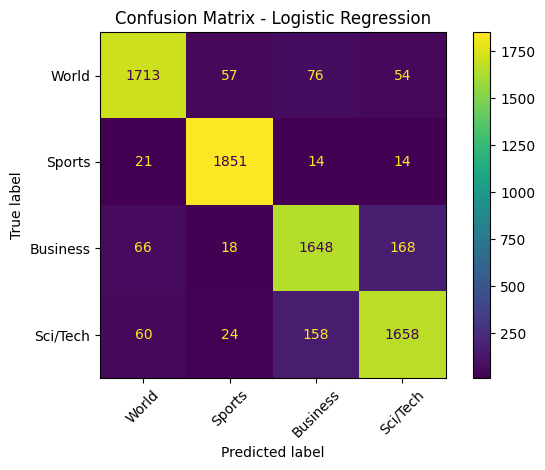

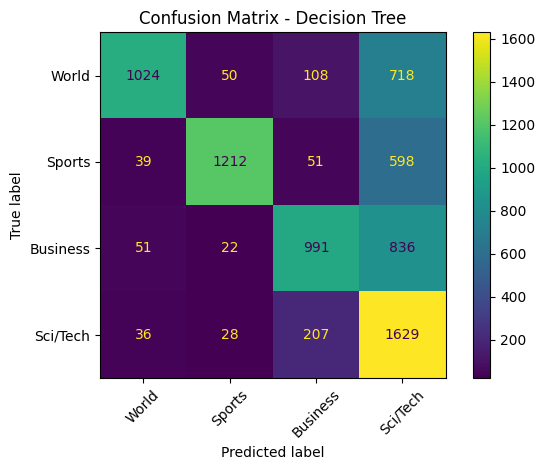

Confusion matrices for both models display


In [18]:
# ============ visualize confusion matrices ============

# logistic Regression Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['World', 'Sports', 'Business', 'Sci/Tech'],
    xticks_rotation=45
)
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

# decision Tree Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['World', 'Sports', 'Business', 'Sci/Tech'],
    xticks_rotation=45
)
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()

print("Confusion matrices for both models display")


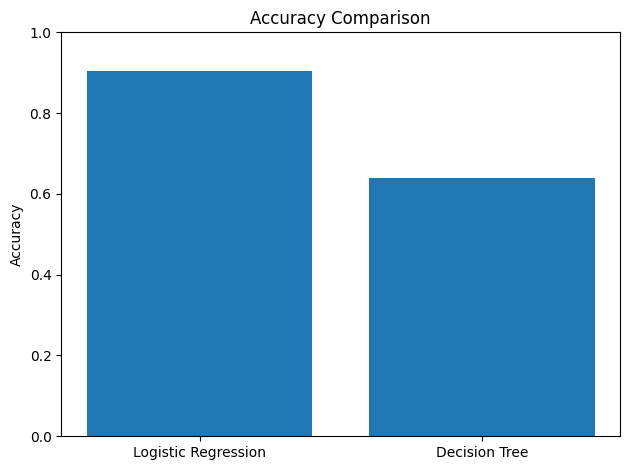

Accuracy comparison plot displayed!


In [19]:
# ============ accuracy comparison between Logistic Regression and Decision Tree ============

# bar chart for accuracy comparison
plt.figure()
plt.bar(["Logistic Regression", "Decision Tree"], [accuracy, accuracy_dt])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Accuracy comparison plot displayed!")


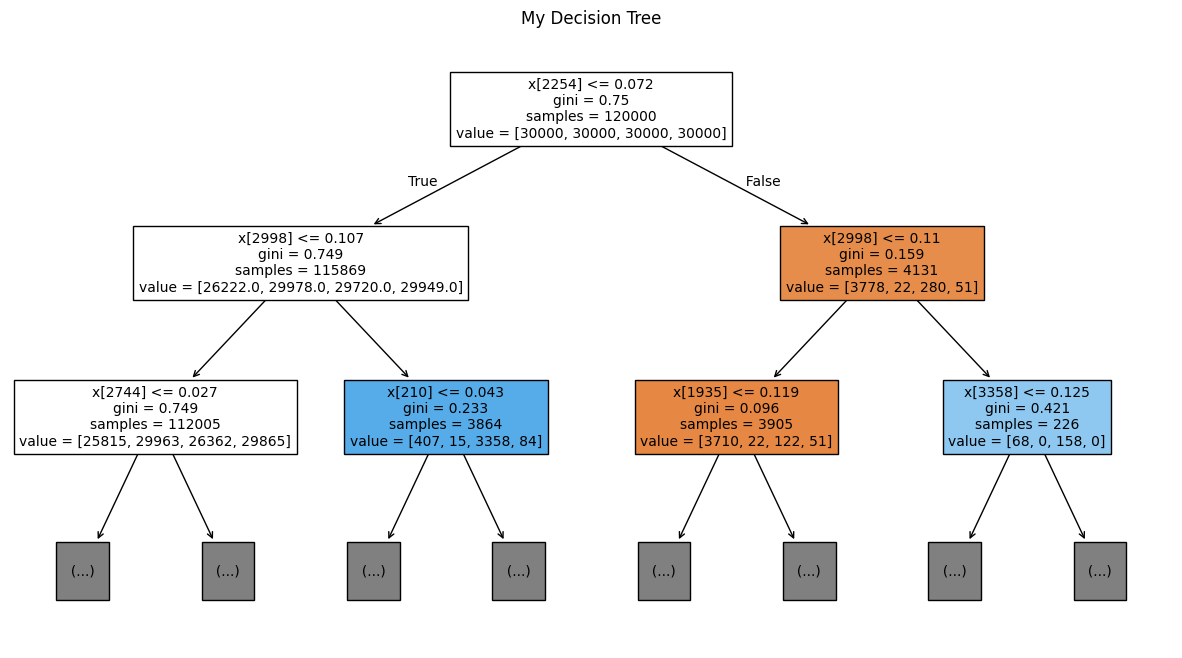

Decision Tree plot displayed!


In [22]:
# ============ plot the Decision Tree ============

from sklearn.tree import plot_tree

# create figure for the plot
plt.figure(figsize=(15, 8))

# plot the decision tree with max_depth=2
plot_tree(dt_model, max_depth=2, filled=True, fontsize=10)

plt.title("My Decision Tree")

plt.show()

print("Decision Tree plot displayed!")
